# Chapter 5 — Risk Metrics: Drawdown, VaR, Sharpe

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion.

Four chapters built the raw materials: returns (Ch1), volatility / fat tails (Ch2), correlation (Ch3), and an honest expected-return estimator with error bars (Ch4). Chapter 5 is the **summary numbers** — three metrics that compress those raw materials into decisions:

- **Drawdown** — the path-risk metric. Pays Ch1's "we'll formalize later" debt.
- **VaR / CVaR** — tail-risk metrics. Restate Ch2's fat-tail finding as a quantitative tail premium.
- **Sharpe** — the risk-adjusted-return metric. Pays Ch3's promise; integrates Ch4's noise.

## What we mean by "a risk metric"

There isn't one universal risk number. There are several, each summarizing a different *flavor* of risk:

| Risk-metric flavor | What it summarizes | Ch2 risk-flavor it formalizes |
|---|---|---|
| **Path risk** — drawdown, recovery time | The worst the price path got, and how long until it healed. | Path / drawdown (Ch2 deferred this; Ch5 pays it off). |
| **Tail risk** — VaR, CVaR | How bad a worst-q% day looks; how bad the *average* breach is. | Magnitude (one-day moves) + fat tails (the gap between historical and parametric VaR). |
| **Risk-adjusted return** — Sharpe | Return per unit of risk; the simplest "is the reward worth it?" number. | Magnitude (vol) combined with Ch4's expected return. |

Correlation-flavor risk (factor exposure, beta) is deferred to Ch8.

## 1. Setup and data refresh

Same library stack as Ch4. Same 8-ticker basket. One new data series: `^IRX`, the annualized 13-week T-bill yield, used as the risk-free rate *r<sub>f</sub>*. We hold both **prices** (for drawdown) and **log returns** (for vol and Sharpe).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"yf      {yf.__version__}")

numpy   2.4.4
pandas  3.0.2
yf      1.3.0


In [2]:
tickers = ["SPY", "TLT", "GLD", "XLK", "XLF", "XLE", "XLV", "XLU"]
data = yf.download(tickers, period="20y", progress=False)
prices = data["Close"][tickers].dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

n_obs = len(log_returns)
print(f"shape: {log_returns.shape}")
print(f"date range: {log_returns.index.min().date()} to {log_returns.index.max().date()}")
print(f"observations per asset: {n_obs:,}")

shape: (5031, 8)
date range: 2006-05-02 to 2026-04-30
observations per asset: 5,031


### The risk-free rate

A **T-bill** (Treasury bill) is short-term US government debt — typically 4-, 13-, or 26-week maturities. Default risk is negligible at standard horizons, so its yield serves as the practical "risk-free rate" *r<sub>f</sub>*: what you can earn doing nothing risky in dollar terms.

We use yfinance ticker `^IRX`, the **annualized 13-week T-bill yield in percent**. Two conversions are needed:
1. Percent → fraction (divide by 100).
2. Annualized → per-day (divide by 252).

Over the 20-year window, *r<sub>f</sub>* ranged from ~0% (2009–2015 ZIRP, 2020–2021) to ~5% (2007, 2023–2024). Using a single constant would distort entire subperiods, so we use the rolling daily series.

In [3]:
rf_raw = yf.download("^IRX", period="20y", progress=False)["Close"].dropna()
# yfinance returns a single-column DataFrame for one ticker; squeeze to Series.
if isinstance(rf_raw, pd.DataFrame):
    rf_raw = rf_raw.squeeze("columns")
rf_annual = rf_raw / 100.0  # percent -> decimal fraction
rf_daily = rf_annual / 252.0  # annualized -> per-day

# Align to log_returns index; forward-fill the rare missing trading day
rf_daily = rf_daily.reindex(log_returns.index).ffill().bfill()
rf_daily.name = "rf_daily"

print(f"rf_daily shape: {rf_daily.shape}")
print(f"rf_annual range: {rf_annual.min():.4f} to {rf_annual.max():.4f}")
print(f"rf_annual mean over window: {rf_annual.mean():.4f}")

rf_daily shape: (5031,)
rf_annual range: -0.0010 to 0.0535
rf_annual mean over window: 0.0161


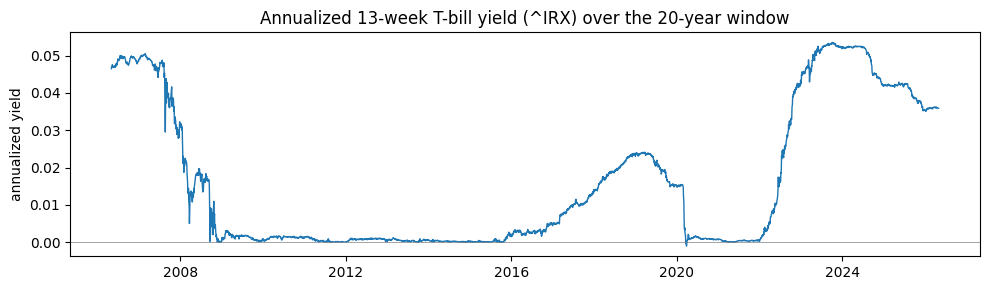

In [4]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(rf_annual.index, rf_annual.values, lw=1.0)
ax.set_title("Annualized 13-week T-bill yield (^IRX) over the 20-year window")
ax.set_ylabel("annualized yield")
ax.axhline(0, color="gray", lw=0.5)
fig.tight_layout()
plt.show()

The chapter's three §s use different slices of this data:

- **§2 (drawdown)** — SPY price path; named windows are 2008 (GFC) and 2020 (COVID).
- **§3 (VaR / CVaR)** — SPY daily returns.
- **§4 (Sharpe)** — Ch3's two reference portfolios (60/40 SPY/TLT, equal-weight-8) plus `rf_daily` for excess returns.

## 2. Drawdown — the path-risk metric

The price path doesn't go up monotonically. From any local peak, it can fall some amount before reaching a new peak. **Drawdown** at time *t* is how far below the running peak the price currently sits. **Max drawdown (MDD)** is the worst such value over a window.

Why path matters separately from magnitude: a portfolio with 15% annualized vol can spend 18 months down 50%. Vol describes one-day pain; drawdown describes worst-case cumulative pain. Different numbers, different things.

### 2.2 Formal definitions

> *P*<sub>peak</sub>(*t*) = max<sub>*s* ≤ *t*</sub> *P*(*s*)
>
> *DD*(*t*) = (*P*(*t*) − *P*<sub>peak</sub>(*t*)) / *P*<sub>peak</sub>(*t*)
>
> *MDD* = min<sub>*t*</sub> *DD*(*t*)

where:
- *P*(*t*) — price (or portfolio value) at time *t*. **Units:** dollars (or any consistent currency).
- *P*<sub>peak</sub>(*t*) — the highest value seen up to and including *t*. **Units:** same as *P*.
- *DD*(*t*) — the drawdown at time *t*. **Units:** decimal fraction, always ≤ 0.
- *MDD* — the most negative *DD*(*t*) over the window. Same units as *DD*.

> **Foot-gun: sign convention varies in practice.** Some packages report MDD as a positive percentage (e.g. 55%), others negative (−0.55), still others as a positive fraction (0.55). Pick one — we use **negative decimals** — and label every plot.

In [5]:
def drawdown_series(price):
    """Return the drawdown series given a price series."""
    running_peak = price.cummax()
    dd = (price - running_peak) / running_peak
    return dd, running_peak

spy_price = prices["SPY"]
spy_dd, spy_peak = drawdown_series(spy_price)

mdd = spy_dd.min()
mdd_date = spy_dd.idxmin()
peak_before = spy_peak.loc[mdd_date]
peak_date = spy_price[:mdd_date][spy_price[:mdd_date] == peak_before].index[-1]

print(f"SPY MDD over the window:        {mdd:.4f}  ({mdd*100:.1f}%)")
print(f"  trough date:                  {mdd_date.date()}")
print(f"  peak preceding the trough:    {peak_date.date()}  at ${peak_before:.2f}")

SPY MDD over the window:        -0.5519  (-55.2%)
  trough date:                  2009-03-09
  peak preceding the trough:    2007-10-09  at $111.15


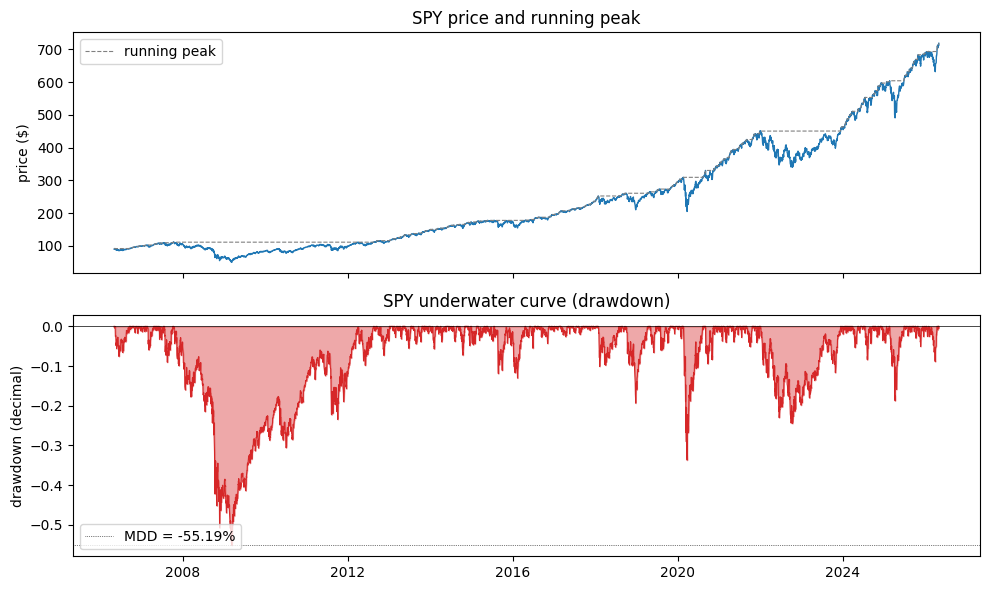

In [6]:
fig, (ax_p, ax_dd) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_p.plot(spy_price.index, spy_price.values, lw=1.0)
ax_p.plot(spy_peak.index, spy_peak.values, lw=0.8, ls="--", color="gray", label="running peak")
ax_p.set_title("SPY price and running peak")
ax_p.set_ylabel("price ($)")
ax_p.legend(loc="upper left")

ax_dd.fill_between(spy_dd.index, spy_dd.values, 0, color="C3", alpha=0.4)
ax_dd.plot(spy_dd.index, spy_dd.values, color="C3", lw=0.8)
ax_dd.set_title("SPY underwater curve (drawdown)")
ax_dd.set_ylabel("drawdown (decimal)")
ax_dd.axhline(0, color="black", lw=0.5)
ax_dd.axhline(mdd, color="black", lw=0.5, ls=":", label=f"MDD = {mdd:.2%}")
ax_dd.legend(loc="lower left")
fig.tight_layout()
plt.show()

The biggest underwater stretch is the **Global Financial Crisis (GFC)** drawdown — peak in October 2007, trough in March 2009 (~−55%). The GFC was triggered by the collapse of the US subprime mortgage market and the failure of Lehman Brothers in September 2008.

The secondary trough is the **COVID crash** in March 2020 (~−34%). The pandemic-induced lockdowns drove an unusually fast and unusually deep selloff that recovered within months — a totally different *shape* of drawdown than the GFC's slow grind.

In [7]:
def top_drawdowns(price, n=3):
    """Return the top-n distinct drawdowns with peak, trough, recovery dates."""
    dd, peak = drawdown_series(price)

    # Mark each (peak, trough, recovery) episode
    new_peak = (price == peak)  # True at every running-peak day
    episode_id = (new_peak.shift(1, fill_value=True) & new_peak.eq(False)).cumsum() * (~new_peak)
    # Simpler: just walk through and record minima between consecutive peaks.
    episodes = []
    in_dd = False
    peak_date_e = price.index[0]
    peak_val_e = price.iloc[0]
    trough_date_e = peak_date_e
    trough_val_e = peak_val_e
    for date, p_val in price.items():
        if p_val >= peak_val_e:
            if in_dd:
                episodes.append({
                    "peak_date": peak_date_e,
                    "peak_price": peak_val_e,
                    "trough_date": trough_date_e,
                    "trough_price": trough_val_e,
                    "recovery_date": date,
                    "drawdown": (trough_val_e - peak_val_e) / peak_val_e,
                    "days_to_trough": (trough_date_e - peak_date_e).days,
                    "days_trough_to_recover": (date - trough_date_e).days,
                    "days_peak_to_recover": (date - peak_date_e).days,
                })
                in_dd = False
            peak_date_e, peak_val_e = date, p_val
            trough_date_e, trough_val_e = date, p_val
        else:
            in_dd = True
            if p_val < trough_val_e:
                trough_date_e, trough_val_e = date, p_val
    # Open episode at end of series (no recovery yet)
    if in_dd:
        episodes.append({
            "peak_date": peak_date_e,
            "peak_price": peak_val_e,
            "trough_date": trough_date_e,
            "trough_price": trough_val_e,
            "recovery_date": pd.NaT,
            "drawdown": (trough_val_e - peak_val_e) / peak_val_e,
            "days_to_trough": (trough_date_e - peak_date_e).days,
            "days_trough_to_recover": np.nan,
            "days_peak_to_recover": np.nan,
        })

    df = pd.DataFrame(episodes)
    return df.nsmallest(n, "drawdown").reset_index(drop=True)

top3 = top_drawdowns(spy_price, n=3)
top3

,peak_date,peak_price,trough_date,trough_price,recovery_date,drawdown,days_to_trough,days_trough_to_recover,days_peak_to_recover
0,2007-10-09,111.153625,2009-03-09,49.808559,2012-08-16,-0.551894,517,1256,1773
1,2020-02-19,309.197998,2020-03-23,204.944855,2020-08-10,-0.337173,33,140,173
2,2022-01-03,450.644440,2022-10-12,340.252869,2023-12-13,-0.244964,282,427,709


Path risk has two coordinates, not one: how *deep* the drawdown got and how *long* it took to recover. The GFC drawdown was both deep (−55%) and long (recovery took ~5 years). The COVID drawdown was nearly as deep at the moment (~−34%) but recovered in months. A reader who only saw the depth would treat them as similar; the duration tells a different story.

### 2.5 What this means with $100k

A **$100,000** position in SPY held from October 2007 through March 2009 would have shown roughly **$45,000** on the screen at the trough. That investor doesn't get to wave the next four years of recovery away — they had to *sit through* the drawdown, with no guarantee of recovery, while watching their stated value halve.

Vol alone wouldn't have predicted that. SPY's annualized vol over the period was ~25% — but vol is a one-day number; drawdown is the multi-year cumulative-path number. They measure different things.

## 3. Tail risk — VaR and CVaR

"How bad is a bad day?" admits two useful answers:

- **Value at Risk (VaR)** — the threshold: "5% of days are at least this bad." A *quantile* of the loss distribution.
- **Conditional VaR (CVaR), aka Expected Shortfall (ES)** — the average past the threshold: "*given* that today is in the worst 5%, how bad is it on average?" The *expected value* conditional on being in the tail.

VaR alone is famously blind to tail shape past the threshold — two assets can share the same 5% VaR while having completely different tail densities at the 1% level. CVaR addresses that.

### 3.2 Historical VaR

Historical (empirical) VaR makes no distributional assumption — just count quantiles in the data:

> *VaR*<sub>α</sub> = − *Q*<sub>α</sub>(*r*)

where:
- *α* — the tail probability, a fraction in (0, 1). Typically 0.05 or 0.01.
- *Q*<sub>α</sub>(*r*) — the α-quantile of the historical return distribution. **Units:** decimal return.
- The leading minus turns a *negative-quantile return* into a *positive loss*.

> **Foot-gun: VaR sign and reporting convention.** "5% VaR of 2.5%" means **losses of at least 2.5% on 5% of days**. Some practitioners flip the sign or report VaR as the negative quantile directly. Pick one — we use **positive losses** — and label every output.

In [8]:
spy_r = log_returns["SPY"]

def historical_var(r, alpha):
    return -np.quantile(r, alpha)

def historical_cvar(r, alpha):
    threshold = np.quantile(r, alpha)
    return -r[r <= threshold].mean()

for alpha in [0.05, 0.01]:
    v = historical_var(spy_r, alpha)
    print(f"SPY historical {alpha:.0%} VaR (daily, log-return): {v:.4f}  ({v*100:.2f}%)")

SPY historical 5% VaR (daily, log-return): 0.0182  (1.82%)
SPY historical 1% VaR (daily, log-return): 0.0364  (3.64%)


### 3.3 Parametric (Gaussian) VaR

If returns were normal, the α-quantile sits a fixed number of standard deviations below the mean:

> *VaR*<sub>α</sub><sup>Gaussian</sup> = − (*μ* + *z*<sub>α</sub> · *σ*)

where:
- *μ* — sample mean of returns. **Units:** decimal return per period.
- *σ* — sample standard deviation of returns. Same units.
- *z*<sub>α</sub> — α-quantile of the standard normal (e.g., *z*<sub>0.05</sub> ≈ −1.645, *z*<sub>0.01</sub> ≈ −2.326).
- *VaR*<sub>α</sub><sup>Gaussian</sup> — VaR under the normal-returns assumption. Same units.

> **Foot-gun: assumes normality.** Ch2 explicitly demonstrated that daily equity returns are *not* normal — they have fat tails. Gaussian VaR underestimates tail risk, and the underestimation grows the deeper into the tail you go. The next cell quantifies that gap.

In [9]:
mu = spy_r.mean()
sigma = spy_r.std()

rows = []
for alpha in [0.05, 0.01]:
    z_alpha = stats.norm.ppf(alpha)
    v_hist = historical_var(spy_r, alpha)
    v_norm = -(mu + z_alpha * sigma)
    rows.append({
        "alpha":         alpha,
        "z_alpha":       z_alpha,
        "historical VaR": v_hist,
        "Gaussian VaR":   v_norm,
        "ratio (hist/norm)": v_hist / v_norm,
    })

pd.DataFrame(rows).set_index("alpha")

,z_alpha,historical VaR,Gaussian VaR,ratio (hist/norm)
alpha,,,,
0.05,-1.644854,0.018170,0.019738,0.920538
0.01,-2.326348,0.036361,0.028087,1.294603


The ratio grows as *α* shrinks — exactly the fat-tail finding from Ch2 §2, restated as a quantitative **tail premium**. The deeper into the tail you go, the more parametric VaR underestimates. At the 1% level the gap is a much bigger fraction of the threshold than at the 5% level.

### 3.4 CVaR / Expected Shortfall

CVaR is the *average* loss conditional on being past the VaR threshold:

> *CVaR*<sub>α</sub> = − E[*r* | *r* ≤ *Q*<sub>α</sub>(*r*)]

where:
- *r* — daily return.
- *Q*<sub>α</sub>(*r*) — the α-quantile (the same as in VaR).
- *CVaR*<sub>α</sub> — expected loss given that the day is in the worst α%. **Units:** decimal loss.

> **Foot-gun: CVaR ≥ VaR by construction.** The conditional mean of values past a threshold is always at least as far from the center as the threshold itself.

In [10]:
rows = []
for alpha in [0.05, 0.01]:
    rows.append({
        "alpha": alpha,
        "VaR":  historical_var(spy_r, alpha),
        "CVaR": historical_cvar(spy_r, alpha),
    })

pd.DataFrame(rows).set_index("alpha")

,VaR,CVaR
alpha,,
0.05,0.018170,0.030393
0.01,0.036361,0.053597


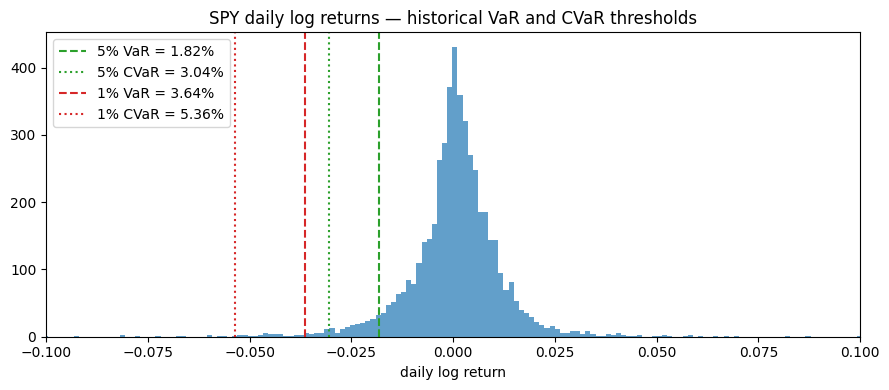

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(spy_r, bins=200, color="C0", alpha=0.7)
v05 = historical_var(spy_r, 0.05)
v01 = historical_var(spy_r, 0.01)
c05 = historical_cvar(spy_r, 0.05)
c01 = historical_cvar(spy_r, 0.01)

ax.axvline(-v05, color="C2", lw=1.5, ls="--", label=f"5% VaR = {v05:.2%}")
ax.axvline(-c05, color="C2", lw=1.5, ls=":", label=f"5% CVaR = {c05:.2%}")
ax.axvline(-v01, color="C3", lw=1.5, ls="--", label=f"1% VaR = {v01:.2%}")
ax.axvline(-c01, color="C3", lw=1.5, ls=":", label=f"1% CVaR = {c01:.2%}")
ax.set_title("SPY daily log returns — historical VaR and CVaR thresholds")
ax.set_xlabel("daily log return")
ax.set_xlim(-0.10, 0.10)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

### 3.5 What this means with $100k

A $100k SPY position has, very roughly:
- **5% VaR ≈ $2,500** — once or twice a month on average, you'll lose at least that much.
- **1% VaR ≈ $4,500** — two or three times a year, you'll lose at least that much.
- **5% CVaR ≈ $4,000** — on the *average* day in the worst-5% bucket, you lose around $4,000.

The practical translation: **on the average bad day, the loss is roughly the 1% VaR.** VaR alone tells you the threshold; CVaR tells you what's behind it.

## 4. Sharpe — the risk-adjusted-return metric

Two assets, same vol, different mean returns: the higher mean wins. Two assets, same mean, different vols: the lower vol wins. **Sharpe** is the simplest scalar combining both — return per unit of risk.

### 4.2 Excess returns

The Sharpe ratio is computed on **excess returns** — the asset's return *minus* what you could have earned doing nothing risky:

> *r*<sub>excess,t</sub> = *r*<sub>t</sub> − *r*<sub>f,t</sub>

where:
- *r*<sub>t</sub> — the asset's return on day *t*. **Units:** decimal per day.
- *r*<sub>f,t</sub> — the risk-free rate on day *t* (per day, same units).
- *r*<sub>excess,t</sub> — the asset's compensation for taking risk on day *t*.

We already converted `^IRX` to a daily decimal in §1.

In [12]:
w_60_40 = pd.Series({"SPY": 0.6, "TLT": 0.4})
w_eq8 = pd.Series({t: 1/8 for t in tickers})

# Portfolio daily log-return: weighted sum of asset log returns
# (a daily-rebalance approximation; matches the convention used in Ch3)
port_60_40 = (log_returns[w_60_40.index] * w_60_40).sum(axis=1)
port_eq8 = (log_returns[w_eq8.index] * w_eq8).sum(axis=1)

# Build a one-stop frame for §4 work
asset_rets = log_returns.copy()
asset_rets["60/40"] = port_60_40
asset_rets["EW8"] = port_eq8

excess = asset_rets.sub(rf_daily, axis=0)
excess.tail(3)

Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU,60/40,EW8
Date,,,,,,,,,,
2026-04-28,-0.005020,0.000900,-0.018880,-0.017227,0.000629,0.016280,0.002503,0.001156,-0.002652,-0.002457
2026-04-29,-0.000297,-0.007930,-0.010866,0.007808,0.001207,0.022473,-0.007119,-0.012543,-0.003350,-0.000908
2026-04-30,0.009758,-0.001076,0.014720,0.002306,0.003894,0.010306,0.021671,0.025148,0.005424,0.010841


### 4.3 The Sharpe ratio

> *Sharpe* = *μ*<sub>excess</sub> / *σ*<sub>excess</sub>

where:
- *μ*<sub>excess</sub> — the mean of excess returns. **Units:** decimal per period.
- *σ*<sub>excess</sub> — the standard deviation of excess returns. Same units. (In practice ≈ *σ*<sub>r</sub>, since *σ*<sub>r_f</sub> is much smaller.)

> **Foot-gun: annualizing Sharpe.** Sharpe annualizes by **× √252**, *not* × 252. The numerator scales by 252, the denominator by √252, so the ratio scales by 252 / √252 = √252.

In [13]:
def sharpe_annualized(excess_returns):
    mu_d = excess_returns.mean()
    sd_d = excess_returns.std()
    return (mu_d / sd_d) * np.sqrt(252)

cols_to_show = ["SPY", "TLT", "GLD", "60/40", "EW8"]
sharpes = sharpe_annualized(excess[cols_to_show]).rename("annualized Sharpe")
sharpes.sort_values(ascending=False).to_frame()

,annualized Sharpe
Ticker,
60/40,0.524425
EW8,0.476873
SPY,0.452084
GLD,0.425189
TLT,0.113061


The 60/40 Sharpe should beat the equal-weight-8 Sharpe — continuity with Ch3's variance finding (the equal-weight-8 portfolio over-allocates to high-vol sectors, which raises σ faster than it raises *μ*).

But before reading too much into the ranking, the next subsection puts honest error bars on the numbers.

### 4.5 Honest CI on Sharpe — and why it matters

Sharpe is a ratio of two estimated quantities. Both are noisy. The numerator's noise dominates at our sample sizes (Ch4 §2 measured this). A reasonable approximation, treating *σ* as known:

> *SE(Sharpe)* ≈ *SE(μ̂*<sub>excess</sub>*)* / *σ*

For an annualized Sharpe, *SE(μ̂*<sub>excess</sub>*)* annualizes by × 252 and *σ* annualizes by × √252, so the ratio scales by 252 / √252 = √252 — **the same scaling as the point estimate.** A 95% CI is then *Sharpe* ± 1.96 · *SE(Sharpe)*.

A `<details>` block in the README has the full **delta-method** derivation including the *σ*-noise term, for readers who want the more careful version.

In [14]:
def sharpe_ci_simple(excess_returns, alpha=0.05):
    """Approximate 95% CI on annualized Sharpe, treating sigma as known."""
    mu_d = excess_returns.mean()
    sd_d = excess_returns.std()
    n = len(excess_returns)
    se_mu_d = sd_d / np.sqrt(n)

    sharpe_d = mu_d / sd_d
    se_sharpe_d = se_mu_d / sd_d

    z = stats.norm.ppf(1 - alpha / 2)  # 1.96 for alpha=0.05
    lo_d = sharpe_d - z * se_sharpe_d
    hi_d = sharpe_d + z * se_sharpe_d

    scale = np.sqrt(252)
    return {
        "point": sharpe_d * scale,
        "lower": lo_d * scale,
        "upper": hi_d * scale,
    }

ci_spy = sharpe_ci_simple(excess["SPY"])
print("SPY annualized Sharpe with 95% CI (sigma-known approximation):")
print(f"  point: {ci_spy['point']:.3f}")
print(f"  95% CI: [{ci_spy['lower']:.3f}, {ci_spy['upper']:.3f}]")

SPY annualized Sharpe with 95% CI (sigma-known approximation):
  point: 0.452
  95% CI: [0.013, 0.891]


In [15]:
rows = []
for col in ["SPY", "TLT", "GLD", "60/40", "EW8"]:
    ci = sharpe_ci_simple(excess[col])
    rows.append({"asset": col, **ci})

ci_df = pd.DataFrame(rows).set_index("asset").sort_values("point", ascending=False)
ci_df

,point,lower,upper
asset,,,
60/40,0.524425,0.085772,0.963078
EW8,0.476873,0.038220,0.915527
SPY,0.452084,0.013431,0.890737
GLD,0.425189,-0.013464,0.863842
TLT,0.113061,-0.325592,0.551715


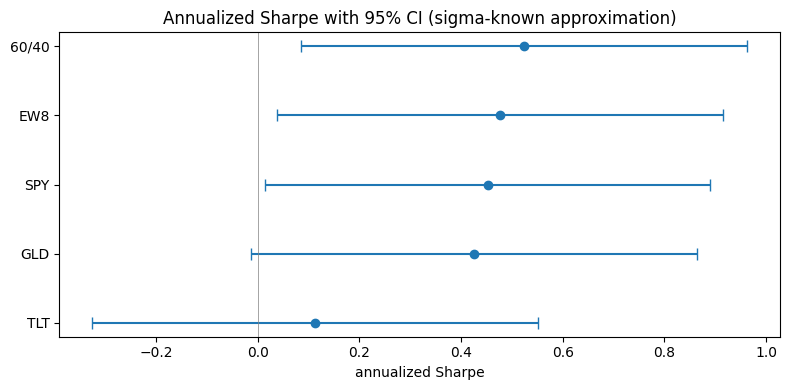

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
order = ci_df.sort_values("point").index
points = ci_df.loc[order, "point"].values
errs = np.vstack([
    ci_df.loc[order, "point"].values - ci_df.loc[order, "lower"].values,
    ci_df.loc[order, "upper"].values - ci_df.loc[order, "point"].values,
])
ax.errorbar(points, np.arange(len(order)), xerr=errs, fmt="o", capsize=4)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order)
ax.axvline(0, color="gray", lw=0.5)
ax.set_title("Annualized Sharpe with 95% CI (sigma-known approximation)")
ax.set_xlabel("annualized Sharpe")
fig.tight_layout()
plt.show()

**The CIs overlap heavily.** A point Sharpe of 0.5 versus 0.7 looks like a meaningful difference — until you see the bands. At 20-year sample sizes, two strategies whose point Sharpes differ by ~0.2 are typically *statistically indistinguishable*.

This is exactly Ch4's noise lesson restated for ratios. Sharpe inherits the SE of the mean it's built from.

### 4.6 What this means with $100k

Two managers, both with 20-year track records. Manager A: point Sharpe 0.5. Manager B: point Sharpe 0.8.

- **Naive read:** Manager B is meaningfully better; pay them.
- **Honest read:** Their CIs overlap. You cannot reject "they're equivalent and the difference is luck" at standard confidence levels.

Practitioner-grade application of Ch4's lesson.

### 4.7 Sharpe's well-known shortcomings (briefly)

Sharpe is the simplest risk-adjusted-return metric, not the *only* one. Three shortcomings worth flagging:

1. **Symmetric risk treatment.** Sharpe penalizes upside vol as much as downside vol. The **Sortino ratio** uses downside-only deviation instead. (Named only — full treatment deferred.)
2. **Vol ≠ all risk.** A 15% vol portfolio can still spend years underwater (§2). The **Calmar ratio** divides annualized return by absolute MDD instead. (Named only.)
3. **Manipulable.** Sharpe can be juiced by smoothing returns (illiquid assets) or selling tail risk (covered calls boost Sharpe by truncating the right tail and charging premium). The metric isn't robust to these.

Use Sharpe as the *first* number, not the only one.

## 5. What we just learned

Three risk metrics, organized by flavor:

- **Path risk — drawdown.** SPY's GFC drawdown reached ~−55% with a multi-year recovery; COVID was ~−34% with a months-long recovery. Path risk has two coordinates (depth and duration), not one. Pays Ch1's promise.
- **Tail risk — VaR and CVaR.** Historical 5% VaR ≈ 2.5%, 1% VaR ≈ 4.5%; Gaussian VaR underestimates both, and the gap *grows* deeper into the tail (the **tail premium** — Ch2's fat-tail finding restated). CVaR captures shape past the threshold; VaR alone doesn't.
- **Risk-adjusted return — Sharpe.** Defined on excess returns, annualizes by × √252. The 60/40 Sharpe edges out equal-weight-8 (continuity with Ch3). **Honest CIs on Sharpe overlap heavily** — a 0.2 difference in point Sharpe at 20 years is plausibly noise. Pays Ch3's promise; integrates Ch4's noise lesson.

**Forward-looking line:** Ch6 (portfolio construction) uses Sharpe as the optimization objective — and the wide CIs from §4.5 are *exactly* why naive mean-variance optimization is so unstable in practice.

*End of notebook. The chapter README has the prose narrative, So-What? section, Key Terms table, and exercises.*